# photutils centers

- we have some examples where photutils is not finding the center, and thus the peak of the radial profile is not at $r=0$
- checking a few examples to see if we are missing some centering code

In [19]:
import os
from astropy.io import fits
from photutils.isophote import EllipseGeometry
from photutils.aperture import EllipticalAperture
from photutils.isophote import EllipseGeometry
from matplotlib import pyplot as plt
import numpy as np
from astropy.visualization import SimpleNorm
from astropy.table import Table

In [2]:
testdir = "/Users/rfinn/research/Virgo/hatools_test/hapy-output-20260330/cutouts/VFID2260-NGC5403-HDI-20170523-p010"
os.chdir(testdir)

In [7]:
tag = os.path.basename(os.getcwd())

In [29]:
rdata = fits.getdata(tag+"-R.fits")
mask = fits.getdata(tag+"-R.fits")
masked_data = np.ma.array(rdata,mask=mask)

In [20]:
mtab = Table.read("/Users/rfinn/research/Virgo/hatools_test/hapy-output-20260330/merged_results.fits")

In [21]:
irow = mtab['VFID'] == "VFID2260"

In [24]:
for c in mtab.colnames:
    if "ELL0" in c:
        print(f"{c}: {mtab[c][irow][0]}")

ELL0_MASKFRAC: --
ELL0_MASK_WARN: False
ELL0_NMASKPIX: --
ELL0_NTOTPIX: --
ELL0_SMA_ARCSEC: 159.93960571289062
ELL0_BA: 0.347515344619751
ELL0_PA_DEG: 141.20228576660156
ELL0_XC: 750.7386239520782
ELL0_YC: 750.720640826002
ELL0_SOURCE: metadata.json


Text(0.5, 1.0, 'VFID2260-NGC5403-HDI-20170523-p010')

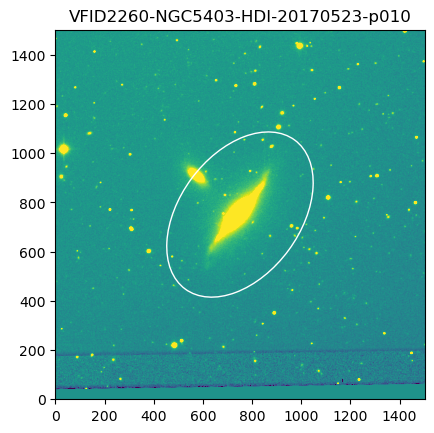

In [31]:

geometry = EllipseGeometry(x0=mtab["ELL0_XC"][irow][0], 
                           y0=mtab["ELL0_YC"][irow][0], 
                           sma=mtab["ELL0_SMA_ARCSEC"][irow][0]/mtab["PIXSCALE"][irow][0], 
                           eps=mtab["ELL0_BA"][irow][0],
                           pa=mtab["ELL0_PA_DEG"][irow][0]-90)
aper = EllipticalAperture((geometry.x0, geometry.y0), geometry.sma,
                          geometry.sma * (1 - geometry.eps),
                          theta=geometry.pa)

snorm = SimpleNorm('sqrt', percent=98)
norm = snorm(masked_data)
plt.imshow(rdata, origin='lower',norm=norm)

aper.plot(color='white')
plt.title(tag)

In [32]:
from photutils.isophote import Ellipse
ellipse = Ellipse(masked_data, geometry=geometry)

In [33]:
isolist = ellipse.fit_image(fit_center=True)

TypeError: Ellipse.fit_image() got an unexpected keyword argument 'fit_center'